## Mini Project by Lisa N. Hananiya
**Dataset: The Tips Dataset from seaborn**

**Date 22/08/2026**

## about the data:
the 'tips' data is a restaurant data example from python seaborn. This data contains variables such as:
| Variable | Meaning |
|----------|---------|
| total_bill | Total bill amount in dollars |
| tip | Tip amount in dollars |
| sex | Gender of the person who paid the bill |
| smoker | Whether the person is a smoker |
| day | Day of the week |
| time | Whether it was lunch or dinner |
| size | Number of people in the group |

Using the 'tips' data, I shall be answering the following questions:
1. Which gender visits the restaurant most between male and female?
2. when do cutomers visits the restaurant the most, lunch time or dinner time?
3. Gender visits per time
4. Which days generate the highest revenue?
5. which days has the highest average bills?
6. Does smoking influence how much tip the customers tip?
7. Do smokers spend more than normal ppeople?
8. Does table size affect spending?
9. Does table size affect tiping?
10. Lunch or dinner? which is more profitable?
11. Which customer segment is most valuable?
12. What predicts a larger tip?
13. Are there unusual customers?


In [650]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [651]:
# load tips dataset from sns and display first five rows and last five rows
tips = sns.load_dataset('tips')
print(tips.head())
tips.tail()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


## Check through data for validity, uniqueness, accuracy, completness, cosistency and statistical values

In [652]:
# Check through data for validity, uniqueness, accuracy, completness, cosistency and statistical values
tips.info()

tips.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


* The above info and statistics shows that the data is in good condition and ready for exploration. 

## Exploratory Data Analysis Section

## Questions to be answered:
1. Which gender visits the restaurant most between male and female?
2. when do cutomers visits the restaurant the most, lunch time or dinner time?
3. Gender visits per time
4. Which days generate the highest revenue?
5. which days has the highest average bills?
6. Does smoking influence how much tip the customers tip?
7. Do smokers spend more than normal ppeople?
8. Does table size affect spending?
9. Does table size affect tiping?
10. Lunch or dinner? which is more profitable?
11. Which customer segment is most valuable?
12. What predicts a larger tip?
13. Are there unusual customers?

### question 1: Which gender visits the restaurant most between male and female?

In [653]:
# sum size per sex
size_per_gender = tips.groupby('sex', observed=True)['size'].sum()

print(size_per_gender)

sex
Male      413
Female    214
Name: size, dtype: int64


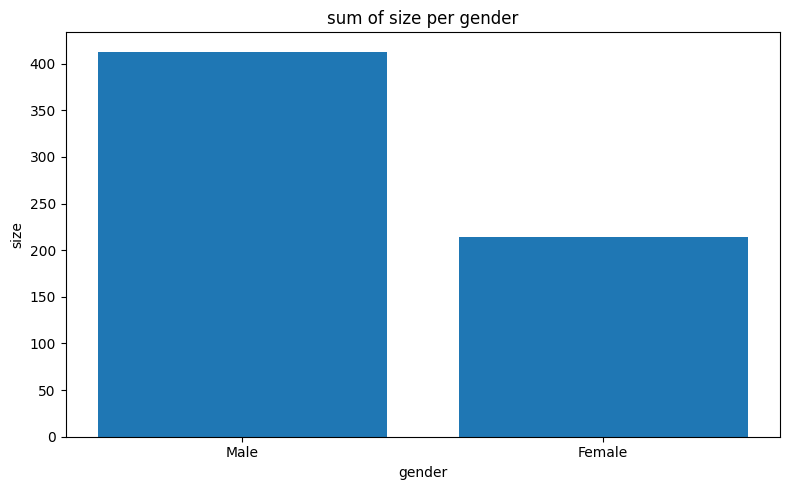

In [654]:
# Visualise which gender visits the restaurant most between male and female
plt.figure(figsize=(8,5))

plt.bar(
    x=size_per_gender.index,
    height=size_per_gender.values
)

plt.xlabel('gender')
plt.ylabel('size')
plt.title('sum of size per gender')
plt.tight_layout()
plt.show()
          

## question 2 & 3 when do cutomers visits the restaurant the most, lunch time or dinner time?

In [655]:
# Sum 'size' grouped by 'sex' and 'time'
Visits_time_per_gender = tips.groupby(['sex','time'], observed=True)['size'].sum().unstack()

Visits_time_per_gender['Total'] = Visits_time_per_gender.sum(axis=1)
Visits_time_per_gender.loc['Total'] = Visits_time_per_gender.sum(axis=0)

print(Visits_time_per_gender)

time    Lunch  Dinner  Total
sex                         
Male       78     335    413
Female     86     128    214
Total     164     463    627


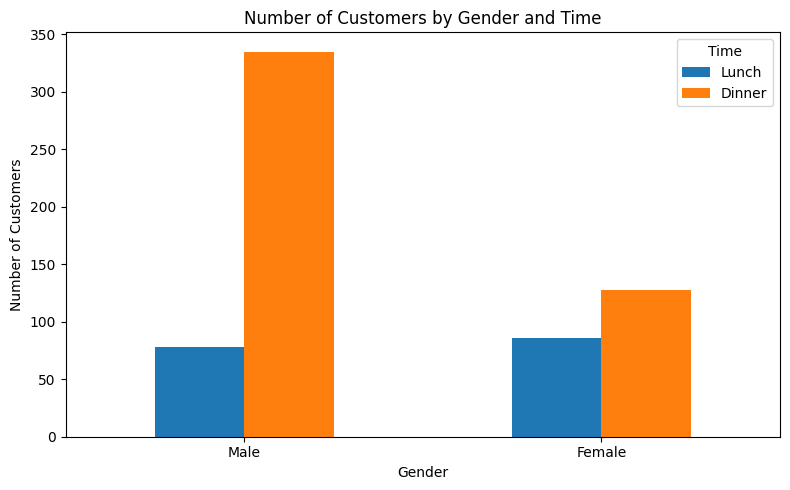

In [656]:
# Extract the Total row and Total column for the chart
chart_data = Visits_time_per_gender.loc[['Male', 'Female'], ['Lunch', 'Dinner']]

chart_data.plot(kind='bar', figsize=(8, 5))

plt.title('Number of Customers by Gender and Time')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Time')
plt.tight_layout()
plt.show()

## Question 4: Which days generate the highest revenue?

In [657]:
# Sum total bill grouped by day
revenue_per_day = (
    tips.groupby('day',observed=True)['total_bill']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='revenue')
)

print(revenue_per_day)

    day  revenue
0   Sat  1778.40
1   Sun  1627.16
2  Thur  1096.33
3   Fri   325.88


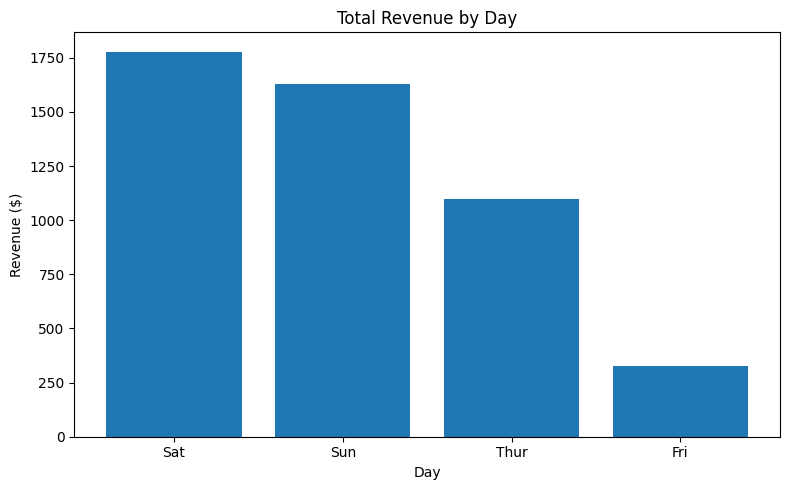

In [658]:
plt.figure(figsize=(8, 5))

plt.bar(revenue_per_day['day'], revenue_per_day['revenue'])

plt.title('Total Revenue by Day')
plt.xlabel('Day')
plt.ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

## **Insight and recommendation**
Saturday, Sunday and Thursdays are days that generate the average to high revenues. For Friday, I recommend running promotions since it generates the lowest revenue while Schedule more staff on the high-revenue days and stock more inventories

## Question 5: which days has the highest average bills?

In [659]:
# Calculate average 'total_bill' grouprd by 'day'
avg_revenue_per_day = (
    tips.groupby('day',observed=True)['total_bill']
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='avg_revenue')
)

print(avg_revenue_per_day)

    day  avg_revenue
0   Sun    21.410000
1   Sat    20.441379
2  Thur    17.682742
3   Fri    17.151579


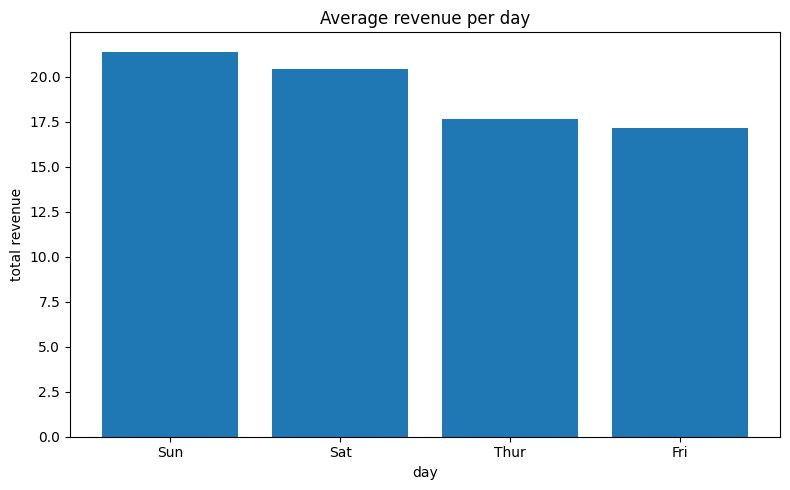

In [660]:
# Average 'total_bill' grouprd by 'day' barplot
plt.figure(figsize=(8,5))
plt.bar(avg_revenue_per_day['day'], avg_revenue_per_day['avg_revenue'])

plt.title('Average revenue per day')
plt.xlabel('day')
plt.ylabel('total revenue')
plt.tight_layout()
plt.show()

## **Insight and recommendation**
Sunday has the highest average bills followed by Saturday. I recommend Promoting premium menu items and offer upsells on those days.

## Question 6: Does smoking influence how much tip the customers tip?

In [661]:
# Group the 'smoker'(yes/no) and calculate tip mean according to each group
tip_by_smoker = (tips.groupby('smoker', observed=True)['tip']
    .mean()
    .reset_index(name='avg_tip')
                )
                 
print(tip_by_smoker)

  smoker   avg_tip
0    Yes  3.008710
1     No  2.991854


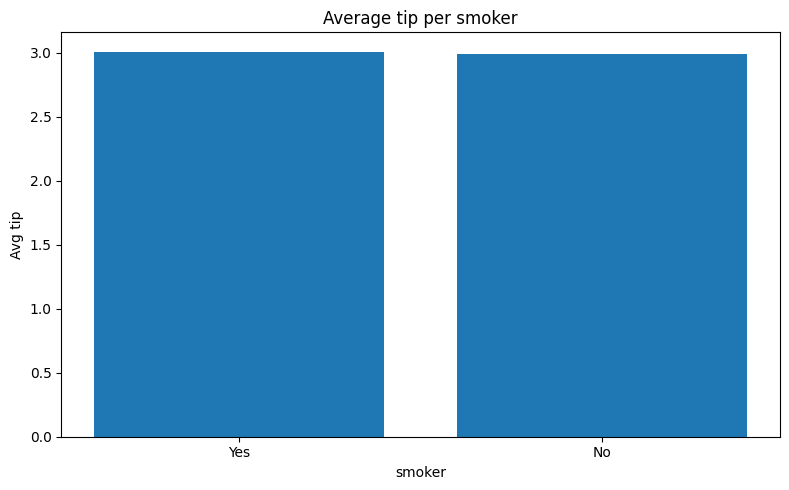

In [662]:
# Bar plot visualising average tip per smoker and non smker to compare
plt.figure(figsize=(8,5))
plt.bar(tip_by_smoker['smoker'], tip_by_smoker['avg_tip'])

plt.title('Average tip per smoker')
plt.xlabel('smoker')
plt.ylabel('Avg tip')
plt.tight_layout()
plt.show()

## Question 7: Do smokers spend more than normal people?

In [663]:
Avg_expense_per_smoker = (tips.groupby('smoker', observed=True)['total_bill']
                          .mean()
                          .reset_index(name='avg_expense')
                          .round(2)
                         )
print(Avg_expense_per_smoker)

  smoker  avg_expense
0    Yes        20.76
1     No        19.19


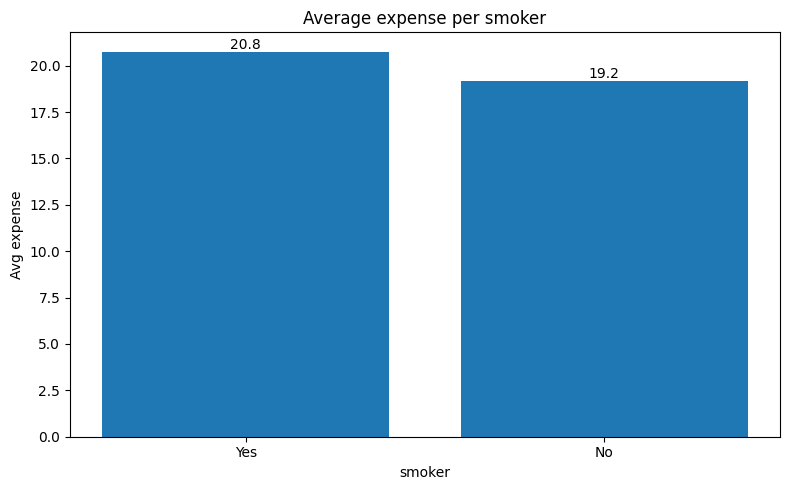

In [664]:
# Plot bar plt for average expense per smoker
plt.figure(figsize=(8,5))
bars = plt.bar(Avg_expense_per_smoker['smoker'],
               Avg_expense_per_smoker['avg_expense']
              )

plt.title('Average expense per smoker')
plt.xlabel('smoker')
plt.ylabel('Avg expense')

# Add values to each of the bar for readabili
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}',
        ha = 'center',
        va = 'bottom'
    )

plt.tight_layout()
plt.show()

## **Insight and recommendation**
Smokers show a slightly higher average spend ($20.76 vs $19.19) and average tip ($3.01 vs $2.99), but a t-test on both total_bill (p=0.20) and tip percentage (p=0.68) shows neither difference is statistically significant. Smoker status is not a reliable predictor of spending or tipping behavior in this data, and shouldn't be used to justify targeted service or marketing decisions.

## Question 8: Does table size affect spending?

In [665]:
# Average total_bill grouped by table size to determine if table size affects spending
avg_expense_per_table_size = (tips.groupby('size', observed=True)['total_bill']
                          .mean()
                          .sort_values(ascending=False)
                          .reset_index(name='avg_expense_per_table').round(2)
                             )
# Adding average expense per individual column to the data frame
avg_expense_per_table_size['avg_expense_per_person']= (avg_expense_per_table_size['avg_expense_per_table']/ avg_expense_per_table_size['size']).round(2)

print(avg_expense_per_table_size[['size','avg_expense_per_table','avg_expense_per_person']])

   size  avg_expense_per_table  avg_expense_per_person
0     6                  34.83                    5.80
1     5                  30.07                    6.01
2     4                  28.61                    7.15
3     3                  23.28                    7.76
4     2                  16.45                    8.22
5     1                   7.24                    7.24


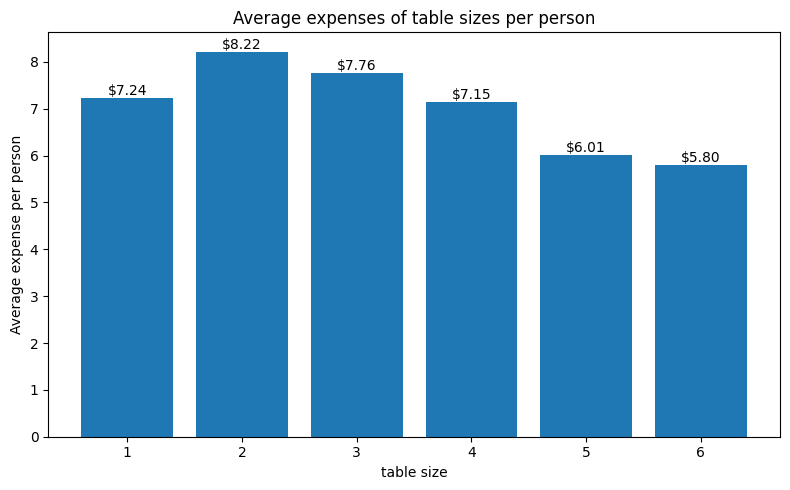

In [666]:
# Visualising average expense per person
plt.figure(figsize=(8,5))

bars = plt.bar(
    avg_expense_per_table_size['size'],
    avg_expense_per_table_size['avg_expense_per_person']
)


plt.title('Average expenses of table sizes per person')
plt.xlabel('table size')
plt.ylabel('Average expense per person')

# Adding value text to each of the bars for readability
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'${bar.get_height():.2f}',
        ha = 'center',
        va = 'bottom'
    )

plt.tight_layout()
plt.show()
            

## Question 9: Does table size affect tiping?

Before answering question 9, I need to create one more column in the dataframe: The 'tip_pct'. This will help in determining how much each table tiped out of their total bills.Hence the question "Does table size affect tiping?" can be deduced.

In [667]:
# Calculating iip percentage column
tips['tip_pct'] = (tips['tip'] / tips['total_bill'] * 100).round(2)

In [668]:
# Gouping the data and calculating average tip percentage per table size
tip_pct_by_table_size = (tips.groupby('size', observed=True)['tip_pct']
                         .mean().round(2)
                         .reset_index(name='tip_pct_per_table')
                        )
print(f'{tip_pct_by_table_size[['size','tip_pct_per_table']]}')

   size  tip_pct_per_table
0     1              21.73
1     2              16.57
2     3              15.21
3     4              14.59
4     5              14.15
5     6              15.62


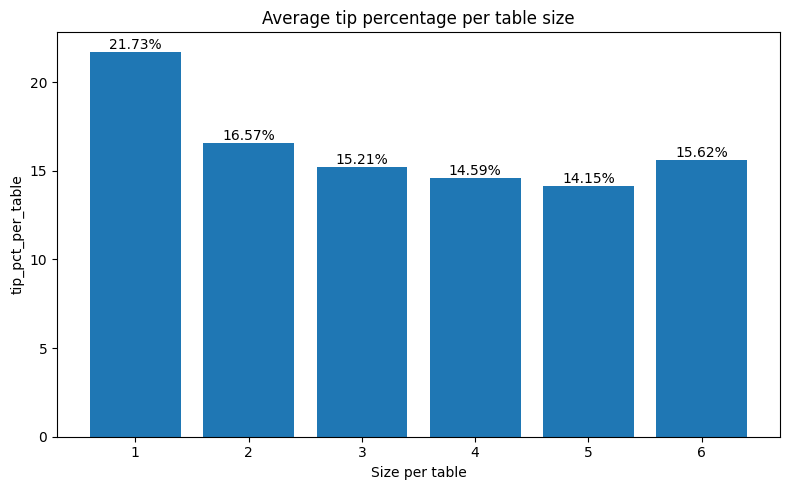

In [669]:
# Visualising average tip percentage per table size
plt.figure(figsize=(8,5))

bars = plt.bar(
    tip_pct_by_table_size['size'],
    tip_pct_by_table_size['tip_pct_per_table']
)
plt.title('Average tip percentage per table size')
plt.xlabel('Size per table')
plt.ylabel('tip_pct_per_table')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height()}%',
        ha = 'center',
        va = 'bottom'
    )

plt.tight_layout()
plt.show()
    

In [670]:
# Check how many tables are in each size group before trusting the averages above
table_size_counts = tips['size'].value_counts().sort_index()
print(table_size_counts)

size
1      4
2    156
3     38
4     37
5      5
6      4
Name: count, dtype: int64


**Insight:** Table sizes of 1, 5, and 6 have very few observations (4, 5, and 4 respectively), compared to 156 tables of size 2. The 21.73% tip percentage for solo diners is based on just 4 data points and should not be treated as a reliable pattern — it could easily be driven by one or two generous customers. The tip percentage trend for sizes 2-4 (14-16%, backed by 150+ tables each) is far more trustworthy.

## Question 10: Lunch or dinner? which is more profitable?

In [671]:
# Group by time, calculate sim of total bill
profit_per_time = (tips.groupby('time', observed=True)['total_bill']
                   .sum()
                  )
print(profit_per_time)

time
Lunch     1167.47
Dinner    3660.30
Name: total_bill, dtype: float64


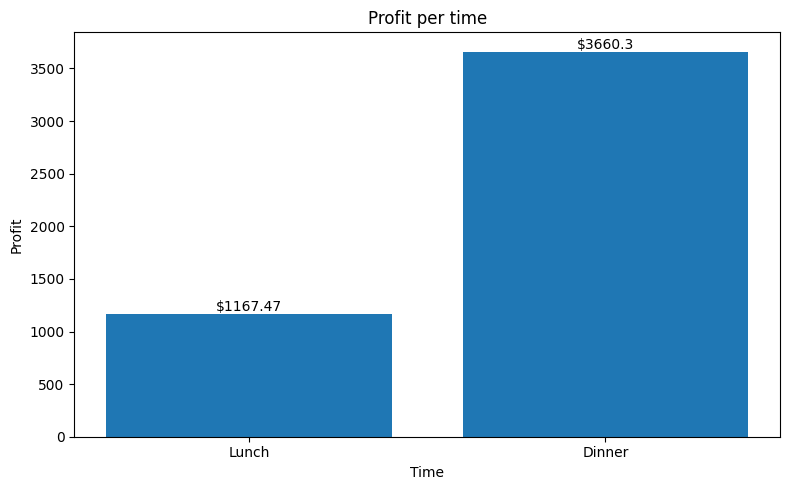

In [672]:
# Visualising profit per time
plt.figure(figsize=(8,5))

bars = plt.bar(
    profit_per_time.index,
    profit_per_time.values
)
plt.title('Profit per time')
plt.xlabel('Time')
plt.ylabel('Profit')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'${bar.get_height()}',
        ha = 'center',
        va = 'bottom'
    )

plt.tight_layout()
plt.show()

## **Insight and recommendation**
The findings shows that dinner is more profitable than lunch. i recommend you consider allocatie more of your competent staffs to dinner time. and also
Run targeted promotions

## Queation 11: Which customer segment is most valuable? (Which combination of day and time produces the highest spending customers?)

In [673]:
# Calculating average of tatal bill grouped by sex
average_bill_per_day_time = (tips.groupby(['day', 'time'], observed=True)['total_bill']
                           .mean()
                           .round(2)
                           .reset_index(name='avg_bill')
                          )
print(average_bill_per_day_time)

    day    time  avg_bill
0  Thur   Lunch     17.66
1  Thur  Dinner     18.78
2   Fri   Lunch     12.85
3   Fri  Dinner     19.66
4   Sat  Dinner     20.44
5   Sun  Dinner     21.41


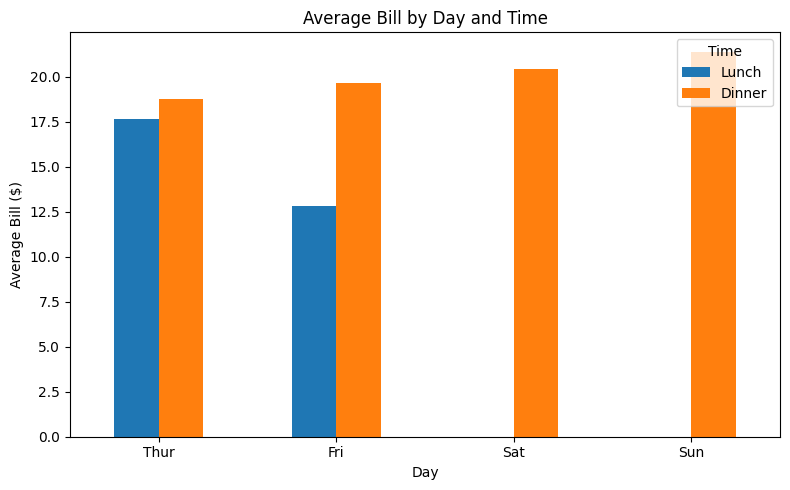

In [674]:
chart_data = average_bill_per_day_time.pivot(
    index='day',
    columns='time',
    values='avg_bill'
)

chart_data.plot(kind='bar', figsize=(8,5))

plt.title('Average Bill by Day and Time')
plt.xlabel('Day')
plt.ylabel('Average Bill ($)')
plt.xticks(rotation=0)
plt.legend(title='Time')
plt.tight_layout()
plt.show()

## **Insight and recommendation**
Focus marketing efforts on sunday and saturdays dinner because that is when customers visist the most

## Question 12: What predicts a larger tip
* total_bill
* size
* day
* time
* smoker

In [675]:
# Correlation between numeric variables and tip
correlation_matrix = tips[['total_bill', 'tip', 'size']].corr()
print(correlation_matrix['tip'].sort_values(ascending=False))

tip           1.000000
total_bill    0.675734
size          0.489299
Name: tip, dtype: float64


In [676]:
# Compare tip across categorical variables to see which matters most
print("Avg tip by day:")
print(tips.groupby('day', observed=True)['tip'].mean().sort_values(ascending=False))

print("\nAvg tip by time:")
print(tips.groupby('time', observed=True)['tip'].mean().sort_values(ascending=False))

print("\nAvg tip by smoker:")
print(tips.groupby('smoker', observed=True)['tip'].mean().sort_values(ascending=False))

Avg tip by day:
day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64

Avg tip by time:
time
Dinner    3.102670
Lunch     2.728088
Name: tip, dtype: float64

Avg tip by smoker:
smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64


## **Insight and recommendation**
Total bill has by far the strongest relationship with tip amount (correlation shown above), bigger bills predict bigger tips, more than any other factor. Day, time, and smoker status all show much weaker relationships. This suggests the best lever for increasing tips isn't staff behavior around specific days/times, but strategies that increase average bill size (upselling), since that's what tips scale with most directly.

## Question 13: Are there unusual customers?

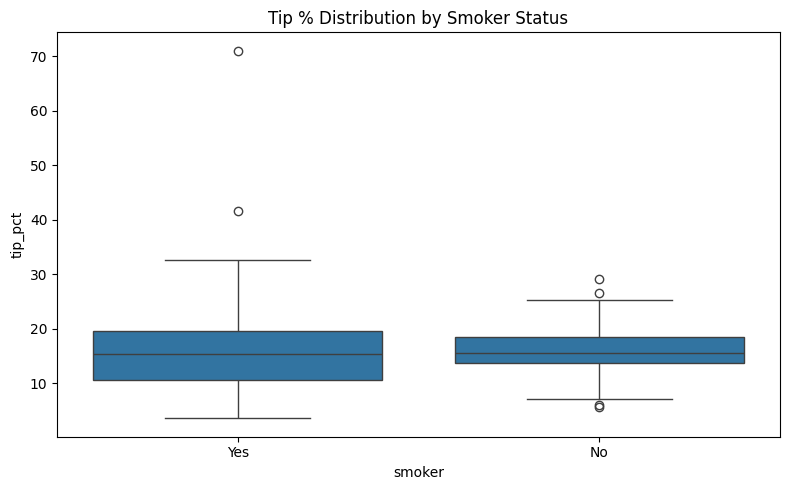

In [677]:
# Boxplot: does smoking affect tip %? — better than a bar of means, shows spread
plt.figure(figsize=(8,5))
sns.boxplot(data=tips, x='smoker', y='tip_pct')
plt.title('Tip % Distribution by Smoker Status')
plt.tight_layout()
plt.show()

## **Insight and recommendation**
For quetion 13, There are few unusual according to the boxplot above. I recommend that you investigate exceptional service experiences, and Identify VIP customers.

# **Statistics Section**

### Is the difference we observe in average tip percentage between smokers and non-smokers large enough that it is unlikely to be due to random sampling variation?

In [678]:
# Import Stats library from scipy
from scipy import stats

In [679]:
# Get tip percentages for each group
smoker = tips[tips['smoker'] == 'Yes'] ['tip_pct']
non_smoker = tips[tips['smoker'] == 'No'] ['tip_pct']

# Independent samples t-test
t_stat, p_value = stats.ttest_ind(
    smoker,
    non_smoker,
    equal_var=False
)

print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.2f}")

t-statistic: 0.41
p-value: 0.68


In [680]:
if p_value < 0.05:
    print("There is a statistically significant difference.")
else:
    print("There is no statistically significant difference.")

There is no statistically significant difference.


 * There is no significant tip difference in mean tip percentage between smokers and non-smokers.

In [681]:
smokers_bill = tips[tips['smoker'] == 'Yes']['total_bill']
non_smokers_bill = tips[tips['smoker'] == 'No']['total_bill']

t_stat, p_value = stats.ttest_ind(
    smokers_bill,
    non_smokers_bill,
    equal_var=False
)
print(f't_stat: {t_stat:.2f}')
print(f'p_value: {p_value:.2f}')

t_stat: 1.28
p_value: 0.20


In [682]:
if p_value < 0.05:
    print("There is a statistically significant difference.")
else:
    print("There is no statistically significant difference.")

There is no statistically significant difference.


* There is no significant tip difference in mean tip percentage between smokers and non-smokers.

## Meaning of p_value in simple terms
A p-value helps us decide whether a difference we see in our data is large enough to take seriously, rather than something that could easily have happened by chance. A high p-value means we don't have strong enough evidence to say the groups are genuinely different, while a low p-value gives us stronger evidence that the difference is probably not just random variation.

In [683]:
from scipy.stats import chi2_contingency

sex_smoker = pd.crosstab(tips['sex'], tips['smoker'])

print(sex_smoker)

smoker  Yes  No
sex            
Male     60  97
Female   33  54


In [684]:
chi2, p_value, dof, expected = chi2_contingency(sex_smoker)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

print("Expected frequencies:")
print(expected)

Chi-square statistic: 0.00
P-value: 1.0000
Degrees of freedom: 1
Expected frequencies:
[[59.84016393 97.15983607]
 [33.15983607 53.84016393]]


In [685]:
if p_value < 0.05:
    print("There is a statistically significant relationship between sex and smoking status.")
else:
    print("There is no statistically significant relationship between sex and smoking status.")

There is no statistically significant relationship between sex and smoking status.


In [686]:
day_time = pd.crosstab(tips['day'], tips['time'])

print(day_time)


time  Lunch  Dinner
day                
Thur     61       1
Fri       7      12
Sat       0      87
Sun       0      76


In [687]:
chi2, p_value, dof, expected = chi2_contingency(day_time)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

print("Expected frequencies:")
print(expected)

Chi-square statistic: 217.11
P-value: 0.0000
Degrees of freedom: 3
Expected frequencies:
[[17.27868852 44.72131148]
 [ 5.29508197 13.70491803]
 [24.24590164 62.75409836]
 [21.18032787 54.81967213]]


In [688]:
if p_value < 0.05:
    print("There is a statistically significant relationship between day and time.")
else:
    print("There is no statistically significant relationship between day and time.")

There is a statistically significant relationship between day and time.


* In this dataset, day of visit and meal time are strongly associated; Saturday and Sunday records are exclusively dinner, while Thursday records are almost exclusively lunch.

## Meaning of chi-square test in simple terms
A chi-square test helps us determine whether two categorical variables appear to be related, rather than their differences simply being due to random variation. It compares what we actually observed with what we would expect to see if there were no relationship, so a small p-value gives us reason to believe the variables are genuinely associated.

In [689]:
import scipy.stats as stats

# tip_pct series from Day 9
data = smoker  
mean = np.mean(data)
sem = stats.sem(data) # standard error of the mean
ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)
print(ci)

(np.float64(14.566166055366395), np.float64(18.072113514526073))


In [690]:
import scipy.stats as stats

# tip_pct series from Day 9
data = non_smoker  
mean = np.mean(data)
ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)
print(ci)

(np.float64(14.188330166051918), np.float64(17.67630559553749))


The confidence intervals overlap substantially, reinforcing the t-test result that there's no reliable difference in tip percentage between smokers and non-smokers.

In [691]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*group1.std()**2 + (n2-1)*group2.std()**2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std

d = round(cohens_d(smoker, non_smoker),2)
print(d)

0.06


The difference in tip percentage between smokers and non-smokers has a very small effect size (Cohen's d = 0.06), suggesting that the difference is unlikely to be practically meaningful.

A result can be statistically significant when the data provide strong evidence that a difference exists, even if the actual difference is too small to matter in the real world. For example, a very large sample might detect a 0.1% difference in tipping that is statistically significant but would have almost no practical value to a restaurant manager.

## **Supervised Learning section**

### **Linear Regression**

In [692]:
     from sklearn.linear_model import LinearRegression
     from sklearn.model_selection import train_test_split

     X = tips[['total_bill']]
     y = tips['tip']

     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

     model = LinearRegression()
     model.fit(X_train, y_train)

     print(f"Slope: {model.coef_[0]:.3f}")
     print(f"Intercept: {model.intercept_:.3f}")

Slope: 0.107
Intercept: 0.925


Slope is = 0.107: This means for every additional on dollar on the total_bill, the predicted tip increases by about $0.107 on average.

In [693]:
# predict tips for the test data:
y_pred = model.predict(X_test)
print(y_pred)

[3.04525623 1.86330727 3.55119456 3.69452593 2.31576375 2.83881627
 3.96728338 2.26014262 2.50615915 2.57033737 2.88160176 2.07723468
 2.06439904 2.47407003 2.00236009 2.91903905 2.92652651 3.23351235
 2.68478854 5.33107064 3.13831465 3.13403611 2.4558862  1.94673896
 3.16077703 2.17564129 2.02375283 3.62927807 2.68906708 6.07767732
 4.99734388 1.75313465 2.83025918 3.09552917 2.74040966 3.50092162
 2.21200895 5.53644096 2.33287794 3.35010279 2.04942412 2.47834858
 3.48701634 2.03017065 2.03124029 1.25361414 2.05798121 2.92438724
 1.73388118]


In [694]:
# Compare actual tips with predicted tips
compare = pd.DataFrame({
    'Actual Tip': y_test.values,
    'Predicted Tip': y_pred
})

compare['error'] = (
    compare['Actual Tip'] - compare['Predicted Tip']
)

print(compare.head())

   Actual Tip  Predicted Tip     error
0        3.18       3.045256  0.134744
1        2.00       1.863307  0.136693
2        2.00       3.551195 -1.551195
3        5.16       3.694526  1.465474
4        2.00       2.315764 -0.315764


In [695]:
# Calculate R2
model_1_r2 = model.score(X_test, y_test)

print(f' r2: {model_1_r2:.3f}')

 r2: 0.545


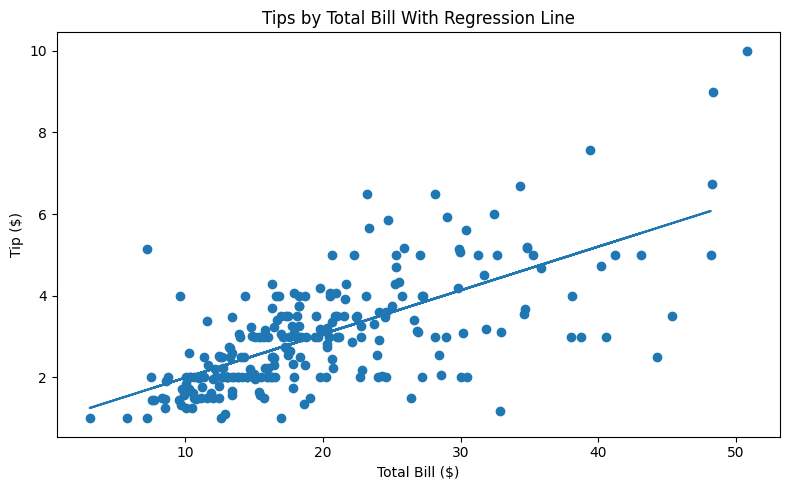

In [696]:
# Visualising what the model learned using scatter plot with regression line
plt.figure(figsize=(8,5))

plt.scatter(tips['total_bill'], tips['tip'])

# regression line 
plt.plot(
    X_test,
    y_pred
)

plt.title('Tips by Total Bill With Regression Line')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')

plt.tight_layout()
plt.show()

Can we predict the tip better if we know both the total bill AND the number of people at the table?

In [697]:
X = tips[['total_bill', 'size']]
y = tips['tip']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model_2_r2 = model.score(X_test, y_test)

print(f' bill and size r2:{model_2_r2:.2f}')


 bill and size r2:0.48


In [698]:
# COmparing model 1 r2 with model 2 r2
print(f'Total biil -> tip: {model_1_r2:.3f}')
print(f'Total bill + size -> tip: {model_2_r2:.3f}')

Total biil -> tip: 0.545
Total bill + size -> tip: 0.481


bill alone seems to predict tip better than when size is added

In [699]:
# Import Mean Absolute Error
from sklearn.metrics import mean_absolute_error

# Calculate Absolute mean Error
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: ${mae:.2f}")

MAE: $0.66


On average, the model's tip prediction is about 66 cents away from the actual tip

### **Classifition: Logistic Regression:**

In [700]:
tips['high_tipper'] = (
    tips['tip_pct'] > 15
).astype(int)
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct,high_tipper
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94,0
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05,1
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66,1
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98,0
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68,0


In [701]:
     from sklearn.linear_model import LogisticRegression
     from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

     X = tips[['total_bill', 'size']]
     y = tips['high_tipper']

     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

     clf = LogisticRegression()
     clf.fit(X_train, y_train)

     y_pred = clf.predict(X_test)
     print("Accuracy:", accuracy_score(y_test, y_pred))
     print(confusion_matrix(y_test, y_pred))
     print(classification_report(y_test, y_pred))

Accuracy: 0.673469387755102
[[ 7 14]
 [ 2 26]]
              precision    recall  f1-score   support

           0       0.78      0.33      0.47        21
           1       0.65      0.93      0.76        28

    accuracy                           0.67        49
   macro avg       0.71      0.63      0.62        49
weighted avg       0.70      0.67      0.64        49



**Precision:** Out of everyone the model flagged as a "generous tipper," how many actually were one? (Measures false alarms.)

**Recall:** Out of everyone who was actually a generous tipper, how many did the model correctly catch? (Measures missed cases.)

**Cross validation of the classification model**; The previous classification model was evaluated on only 49 test observations. Cross-validation lets us see whether the model performs consistently across different portions of the data.

In [702]:
from sklearn.model_selection import cross_val_score


X = tips[['total_bill', 'size']]
y = tips['high_tipper']

clf = LogisticRegression()

scores = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Scores for each fold:", scores)
print(f"Mean accuracy: {scores.mean():.3f}")
print(f"Standard deviation: {scores.std():.3f}")

Scores for each fold: [0.59183673 0.69387755 0.48979592 0.69387755 0.70833333]
Mean accuracy: 0.636
Standard deviation: 0.084


**Classification if Linear Regression Model**; Let's give the model several opportunities to prove itself instead of judging it based on one particular test set.

In [703]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X = tips[['total_bill', 'size']]
y = tips['tip']

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R² scores for each fold:", scores)
print(f"Mean R²: {scores.mean():.3f}")
print(f"Standard deviation: {scores.std():.3f}")

R² scores for each fold: [0.53404571 0.61085627 0.51123501 0.25355216 0.41897975]
Mean R²: 0.466
Standard deviation: 0.122


A single train/test split can give an unstable estimate of model performance because the result depends on which observations happen to land in the test set. In my five-fold cross-validation for the classification model, accuracy ranged from about 49% to 71% across folds (mean 63.6%, std 0.084) — a wide enough swing that my original single-split accuracy of 67.3% could easily have landed on the lucky side. The mean cross-validation accuracy of 63.6% is a more honest estimate of how this model would actually perform on new data.

For the linear regression model, R² varied even more — from 0.25 to 0.61 across folds (mean 0.466) — noticeably lower than the 0.545 I got from a single train/test split. This shows my earlier single-split evaluation was likely too optimistic, and that the regression model's real-world performance is less stable than one good split made it look.

In [704]:
# Encoding categorical variables to add to bill and size predictors
tips_encoded = pd.get_dummies(
    tips,
    columns=['sex', 'smoker', 'day', 'time'],
    drop_first=True
)

tips_encoded.head()

,total_bill,tip,size,tip_pct,high_tipper,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,1.01,2,5.94,0,True,True,False,False,True,True
1,10.34,1.66,3,16.05,1,False,True,False,False,True,True
2,21.01,3.50,3,16.66,1,False,True,False,False,True,True
3,23.68,3.31,2,13.98,0,False,True,False,False,True,True
4,24.59,3.61,4,14.68,0,True,True,False,False,True,True


In [705]:
X = tips_encoded[
    [
        'total_bill',
        'size',
        'sex_Female',
        'smoker_No',
        'day_Fri',
        'day_Sat',
        'day_Sun',
        'time_Dinner'
    ]
]

y = tips_encoded['high_tipper']
cif = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    cif,
    X,
    y,
    cv=5,
    scoring='accuracy'
)
print("Scores:", scores)
print(f"Mean accuracy: {scores.mean():.3f}")
print(f"Standard deviation: {scores.std():.3f}")

Scores: [0.51020408 0.6122449  0.42857143 0.65306122 0.58333333]
Mean accuracy: 0.557
Standard deviation: 0.080


In [706]:
# linear regression inclusing the encoded fetures to predict high tipers
X = tips_encoded[
    [
        'total_bill',
        'size',
        'sex_Female',
        'smoker_No',
        'day_Fri',
        'day_Sat',
        'day_Sun',
        'time_Dinner'
    ]
]

y = tips_encoded['tip']

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R² scores:", scores)
print(f"Mean R²: {scores.mean():.3f}")
print(f"Standard deviation: {scores.std():.3f}")

R² scores: [0.52819606 0.59245311 0.40773384 0.20031853 0.37843167]
Mean R²: 0.421
Standard deviation: 0.135


* The original logistic regression model achieved a mean cross-validation accuracy of 0.636, while the model including categorical variables achieved 0.557. The additional features therefore reduced predictive performance. This suggests that most of the predictive information is already captured by total bill and table size.
* The original linear regression model achieved a mean (r2) cross-validation of 0.466, while the model including categorical variables achieved  0.421. The additional features therefore reduced predictive performance. This suggests that most of the predictive information is already captured by total bill and table size.

### **Decision Tree**
which features actually matter for predicting a generous tipper?" Logistic regression coefficients can answer this, but decision trees give you a more intuitive, visual answer.

In [707]:
# Import decision tree library
from sklearn.tree import DecisionTreeClassifier

X = tips_encoded[
    [
        'total_bill',
        'size',
        'sex_Female',
        'smoker_No',
        'day_Fri',
        'day_Sat',
        'day_Sun',
        'time_Dinner'
    ]
]

y = tips_encoded['high_tipper']

# Prepare the data for training the decision tree
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Train the model
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [708]:
# Calculate the scores 
scores = cross_val_score(
    clf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Scores for each fold:", scores)
print(f"Mean accuracy: {scores.mean():.3f}")
print(f"Standard deviation: {scores.std():.3f}")

Scores for each fold: [0.6122449  0.57142857 0.53061224 0.67346939 0.58333333]
Mean accuracy: 0.594
Standard deviation: 0.048


* Logistic regression accuracy:  0.557
* Decision tree accuracy:        0.594

In [709]:
# Calculate the feature importance
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': clf.feature_importances_
})

importance = importance.sort_values(
    'importance',
    ascending=False
)

print(importance)

       feature  importance
0   total_bill    0.741209
3    smoker_No    0.139930
2   sex_Female    0.063461
7  time_Dinner    0.055400
1         size    0.000000
4      day_Fri    0.000000
5      day_Sat    0.000000
6      day_Sun    0.000000


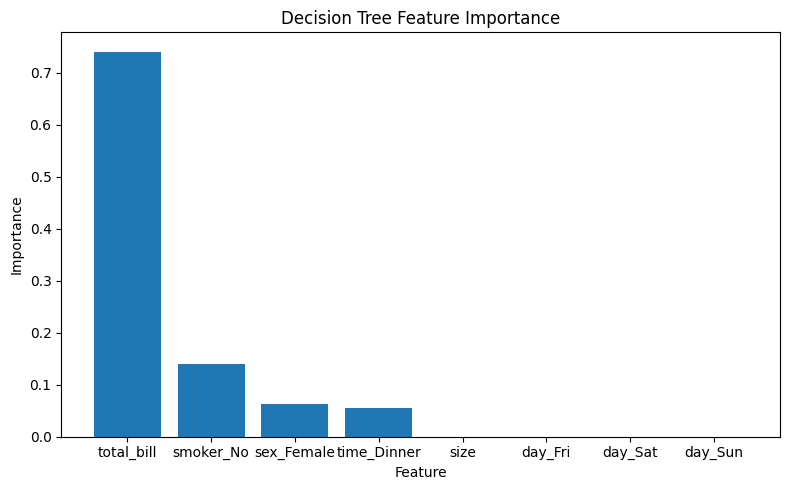

In [710]:
# Display the Feature importance values per each feature
plt.figure(figsize=(8, 5))

plt.bar(
    importance['feature'],
    importance['importance']
)

plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Decision Tree Feature Importance')

plt.tight_layout()
plt.show()

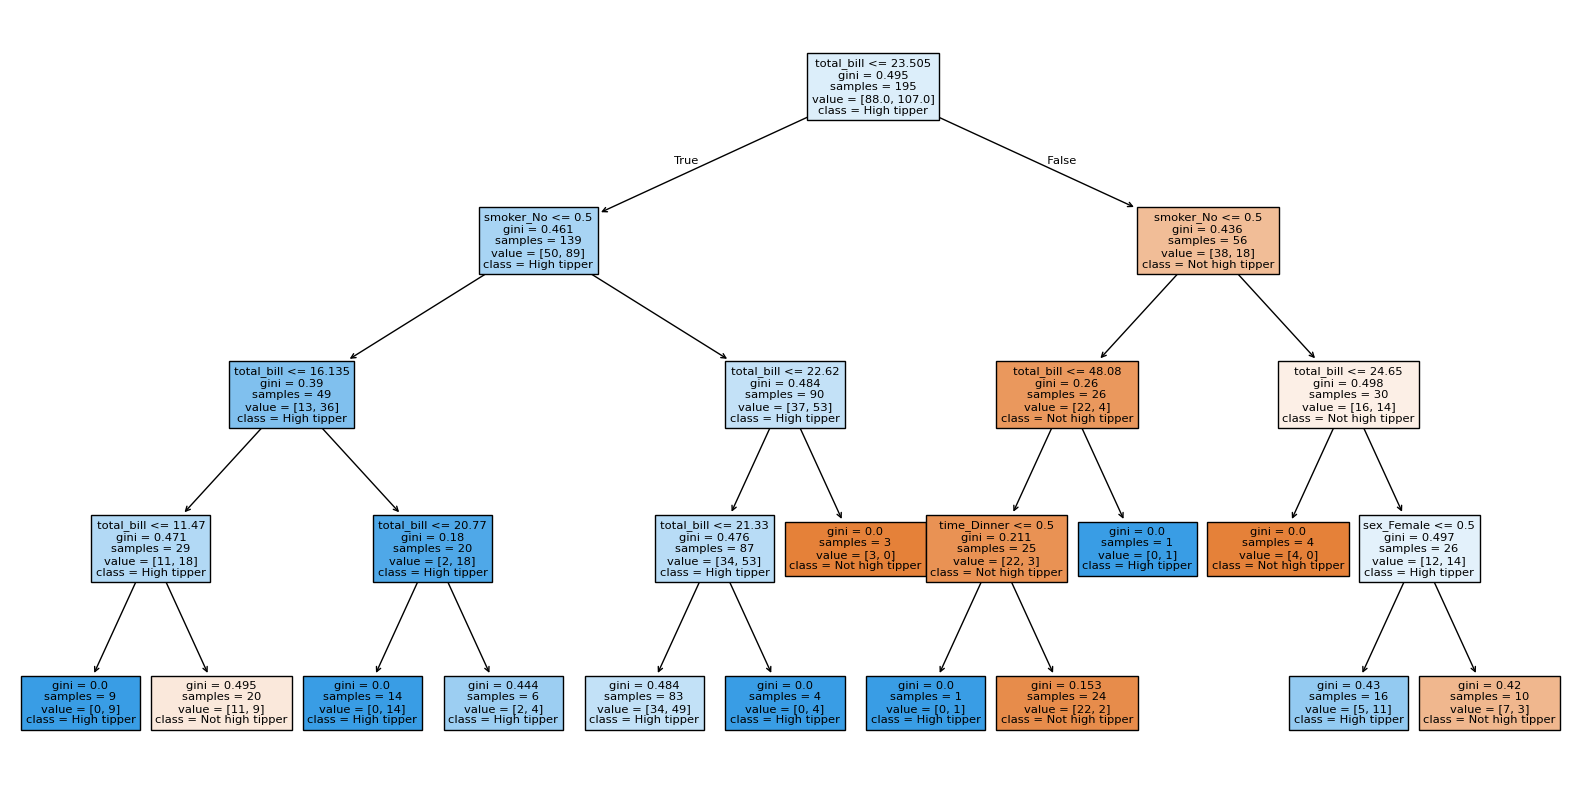

In [711]:
# Visualise the tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['Not high tipper', 'High tipper'],
    filled=True
)

plt.show()

The decision tree's mean cross-validation accuracy was 0.594, compared with 0.557 for the logistic regression model. The most important feature was total_bill [0.741], followed by smoker_no [0.139], and sex_Female [0.063].

### **Random Forest**

In [712]:
# Import Randomforest classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

In [713]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Scores for each fold:", scores)
print(f"Mean accuracy: {scores.mean():.3f}")
print(f"Standard deviation: {scores.std():.3f}")

Scores for each fold: [0.63265306 0.6122449  0.48979592 0.6122449  0.64583333]
Mean accuracy: 0.599
Standard deviation: 0.056


| Model               |   Mean accuracy |
| ------------------- | --------------: |
| Logistic Regression |           0.557 |
| Decision Tree       |           0.594 |
| Random Forest       |           0.599 |


In [714]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [715]:
randomforest_importance = pd.DataFrame({
    'features': X_train.columns,
    'importance': rf.feature_importances_
})
randomforest_importance = randomforest_importance.sort_values(
    'importance',
    ascending=False
)
print(randomforest_importance)

      features  importance
0   total_bill    0.524894
1         size    0.151397
3    smoker_No    0.095888
2   sex_Female    0.073369
5      day_Sat    0.050049
7  time_Dinner    0.039706
4      day_Fri    0.034249
6      day_Sun    0.030449


In [716]:
# Compare the two decision trees
tree_importance = pd.DataFrame({
    'feature': X_train.columns,
    'tree_importance': clf.feature_importances_
})

rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'rf_importance': rf.feature_importances_
})

comparison = tree_importance.merge(
    rf_importance,
    on='feature'
)

comparison = comparison.sort_values(
    'rf_importance',
    ascending=False
)

print(comparison)

       feature  tree_importance  rf_importance
0   total_bill         0.741209       0.524894
1         size         0.000000       0.151397
3    smoker_No         0.139930       0.095888
2   sex_Female         0.063461       0.073369
5      day_Sat         0.000000       0.050049
7  time_Dinner         0.055400       0.039706
4      day_Fri         0.000000       0.034249
6      day_Sun         0.000000       0.030449


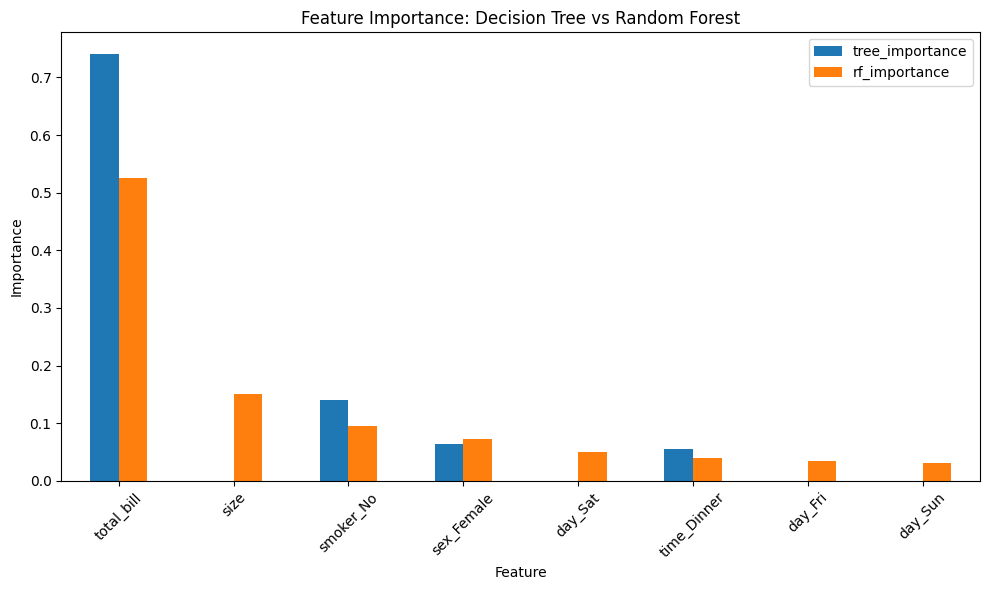

In [717]:
# Visualise the comparison
comparison.plot(
    x='feature',
    y=['tree_importance', 'rf_importance'],
    kind='bar',
    figsize=(10, 6)
)

plt.title('Feature Importance: Decision Tree vs Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Comparing the single decision tree to the random forest reveals two things. First, smoker_No's importance dropped from 0.140 (rank #2) to 0.096 (rank #3) in the forest consistent with my earlier suspicion that the single tree may have overstated its importance, though it hasn't disappeared entirely, so it may carry a weak real signal rather than pure noise.

More striking: the single tree gave `size` zero importance it never appeared in any split while the random forest ranks it as the second most important feature (0.151), well above smoker_No. This shows a single tree's structure can completely miss a genuinely useful feature depending on which splits it happens to choose first. The random forest, by averaging across many trees built on different random subsets, recovered a real signal the single tree discarded entirely the clearest evidence yet that one tree's importance ranking shouldn't be trusted on its own.

## **Final Model Comparison**

### **Regression Models; Predicting Tip Amount**
| Model                              |        R² |
| ---------------------------------- | --------: |
| Linear Regression — single split   | **0.545** |
| Linear Regression — 5-fold CV mean | **0.466** |
The single-split model using total_bill alone achieved an R² of 0.545, while the model using total_bill + size achieved 0.481. the 5-fold cross-validation for the total_bill + size model gave a mean R² of 0.466, showing that performance was somewhat lower and less stable when tested across different subsets of the data.

I also found that adding the categorical variables reduced the cross-validated R² further to 0.421.

### **Classification Models; Predicting High Tipper**
| Model               | Mean CV Accuracy |
| ------------------- | ---------------: |
| Logistic Regression |        **0.557** |
| Decision Tree       |        **0.594** |
| Random Forest       |        **0.599** |
The Random Forest performed best, but only slightly. Its mean accuracy of 0.599 was only 0.005 higher than the Decision Tree's 0.594.

## **Key Findings**
* Total bill is the strongest predictor of tip amount

total_bill was consistently the most useful variable in the predictive models. The simple linear regression explained about 54.5% of the variation in tips on its single test split, while the decision tree gave total_bill a feature importance of 0.741.

* Adding table size did not improve the linear regression model

Adding size actually reduced the single-split R² from 0.545 to 0.481, and the cross-validated mean R² for the total_bill + size model was 0.466. This suggests that, in this dataset, table size adds limited predictive information once total bill is known.

* The sex difference in tip percentage was not practically meaningful

Although the raw averages suggested a difference in tip percentage between males and females, my analysis did not provide strong evidence that the difference was meaningful. This is a good example of why comparing raw averages alone can be misleading.

* Smoking status looked more important in the single tree than in the Random Forest

The single decision tree ranked smoker_No as the second most important feature (0.140). Its importance fell to 0.096 in the Random Forest, suggesting that the single tree may have somewhat overstated the importance of smoking status.

* The Random Forest revealed that table size contained useful predictive information

Interestingly, the single decision tree gave size 0 importance, while the Random Forest ranked it second (0.151). This demonstrates why relying on a single decision tree's feature ranking can be misleading.

* More variables did not necessarily produce a better model

Adding sex, smoker, day, and time actually reduced cross-validated performance: classification accuracy fell from 0.636 to 0.557, while regression R² fell from 0.466 to 0.421. For this dataset, total_bill and size contained more useful predictive information than simply adding every available variable.

## **Lmitations**
This analysis is based on the relatively small tips dataset and does not contain enough business context to establish why customers tip more or less. Some groups, such as certain table sizes, contain relatively few observations, so conclusions about those groups should be treated cautiously. The models also show associations and predictive patterns rather than proving that any variable causes tipping behaviour.

## **Advice to the Restaurant Manager**
The clearest finding is that the size of the customer's bill is strongly associated with the amount they tip, so higher-value tables generally generate higher tips. However, the analysis does not provide strong evidence that customer characteristics such as sex, smoking status, day, or meal time should be used to make major business decisions about tipping. I would focus management attention on increasing overall customer spending through good service and customer experience rather than targeting particular customer groups, while collecting richer restaurant-specific data before making operational decisions.

<br>

<div align="center">
    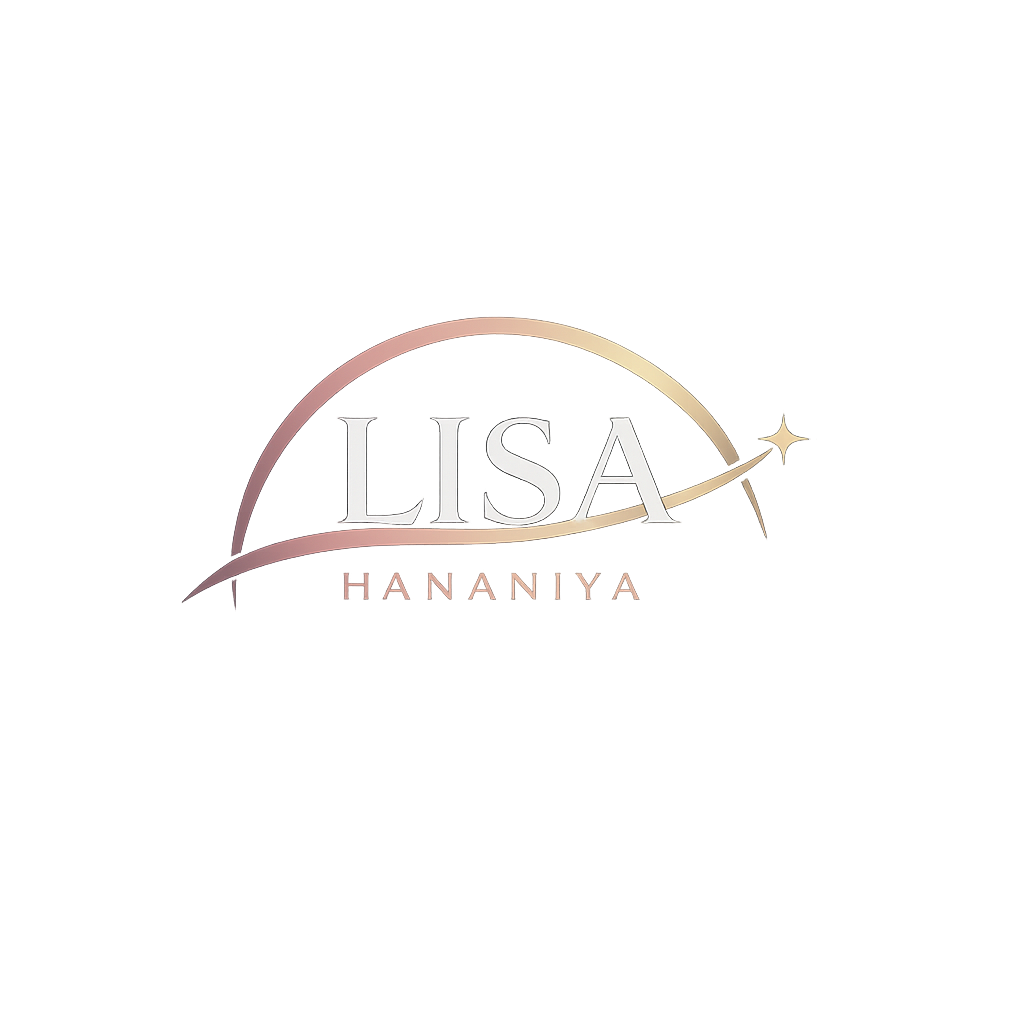
    <br>
    <i>Data Science • Analytics • Continuous Learning</i>
</div>